# 电信月度网络KPI:数据使用量柱状图叠加ARPU与流失率折线(PROC GBARLINE)

## 摘要

本笔记本使用 **PROC GBARLINE** 将月度移动数据使用量的垂直柱状图与ARPU、流失率、支持工单的折线图叠加在一起——这是电信分析师常用的经典"双轴"KPI仪表盘,用于判断使用量的上升是否真正转化为收入和客户留存。它内联生成合成的逐用户记录,然后通过子分组、自定义右轴、参考符号和图例来演练 BAR 和 LINE 语句。

## 数据来源

**数据集:`telco_kpi`** —— 合成的逐用户-月度记录(4个月 x 3个套餐等级 x 8个用户 = 96行),使用 `call streaminit(20260531)` 内联生成。该面板保持在96行,以便完全在非授权模式100个观测的上限之内,使每个月份和套餐等级都能完整呈现。

| 变量 | 类型 | 描述 |
|----------|------|-------------|
| `month`  | 字符型 | 日历月份标签(1月-4月) |
| `plan`   | 字符型 | 套餐等级:预付费、后付费、家庭套餐 |
| `data_gb`| 数值型  | 每月消耗的移动数据量,单位GB(伽马分布,带有温和的季节性提升和缓慢增长) |
| `arpu`   | 数值型  | 每用户平均收入,单位美元(随套餐等级和月份上升) |
| `churn`  | 数值型  | 月度流失标志(0/1,伯努利分布;在期初和较低套餐等级中更高) |
| `tickets`| 数值型  | 开出的支持工单数(泊松计数) |

# 使用 PROC GBARLINE 的电信月度网络KPI

电信运营商的生死取决于少数几个月度KPI:用户消耗了多少**数据**、这些消耗产生了多少**ARPU**(每用户平均收入)、有多少客户**流失**,以及由此带来的**支持工单**负担。这些指标处于截然不同的量级——千兆字节、美元和小额计数——因此绘制在单一响应轴上会掩盖故事的全貌。

`PROC GBARLINE` 正是为此而生:它针对左轴绘制垂直**柱状图**,并针对独立的右轴叠加一条或多条**折线图**。在本笔记本中,我们构建一个使用量与收入的仪表盘,然后逐步加入套餐级子分组、自定义右轴和多条折线叠加。

## 步骤1 —— 生成合成的逐用户-月度数据

下面的DATA步骤构建了一个逼真的面板:4个月(1月-4月)跨3个套餐等级(预付费、后付费、家庭套餐),每个套餐8个用户,共96行。我们使用 `call streaminit` 固定随机数种子以保证可重现性,并从领域适当的分布中抽取每个KPI:

- **数据使用量**来自伽马分布,带有温和的季节性提升和逐月缓慢增长。
- **ARPU** 随套餐等级和月份上升,并带有正态噪声。
- **流失率**作为伯努利标志,在期初和较便宜的套餐等级中更高。
- **支持工单**作为泊松计数,在期初略高。

不读取任何外部文件——一切都是自包含的,96行的面板保持在非授权模式100个观测的上限之内,因此每个月份和套餐等级都能渲染出来。

In [1]:
数据 telco_kpi;
    调用 streaminit(20260531);
    长度 month $10 plan $20;
    循环 mi = 1 到 4;
        如果      mi = 1 那么 month = "1月";
        否则 如果 mi = 2 那么 month = "2月";
        否则 如果 mi = 3 那么 month = "3月";
        否则                 month = "4月";
        /* gentle seasonal lift and slow data growth */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        循环 plan_i = 1 到 3;
            如果 plan_i = 1 那么 plan = "预付费";
            否则 如果 plan_i = 2 那么 plan = "后付费";
            否则 plan = "家庭套餐";
            循环 rep = 1 到 8;
                /* monthly mobile data consumed (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* average revenue per user ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* monthly churn flag, higher early in year */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* support tickets opened */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                输出;
            结束;
        结束;
    结束;
    删除 mi plan_i rep season;
运行;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 步骤2 —— 核心仪表盘:使用量柱状图 + ARPU折线

这是典型的 `GBARLINE` 模式。`BAR` 语句绘制月度平均数据使用量(`SUMVAR=data_gb TYPE=mean`),单个 `LINE` 语句在右轴叠加平均ARPU(`STAT=mean TYPE=join`)。我们打开ODS图形并为图表添加两行标题。`COUTLINE=` 和 `WIDTH=` 用于美化柱状图。

                                                     月度移动数据使用量与ARPU                                                     
                                                    模拟电信网络关键指标(KPI)                                                     




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to 月度移动数据使用量与ARPU.
NOTE: Option TITLE2 changed to 模拟电信网络关键指标(KPI).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


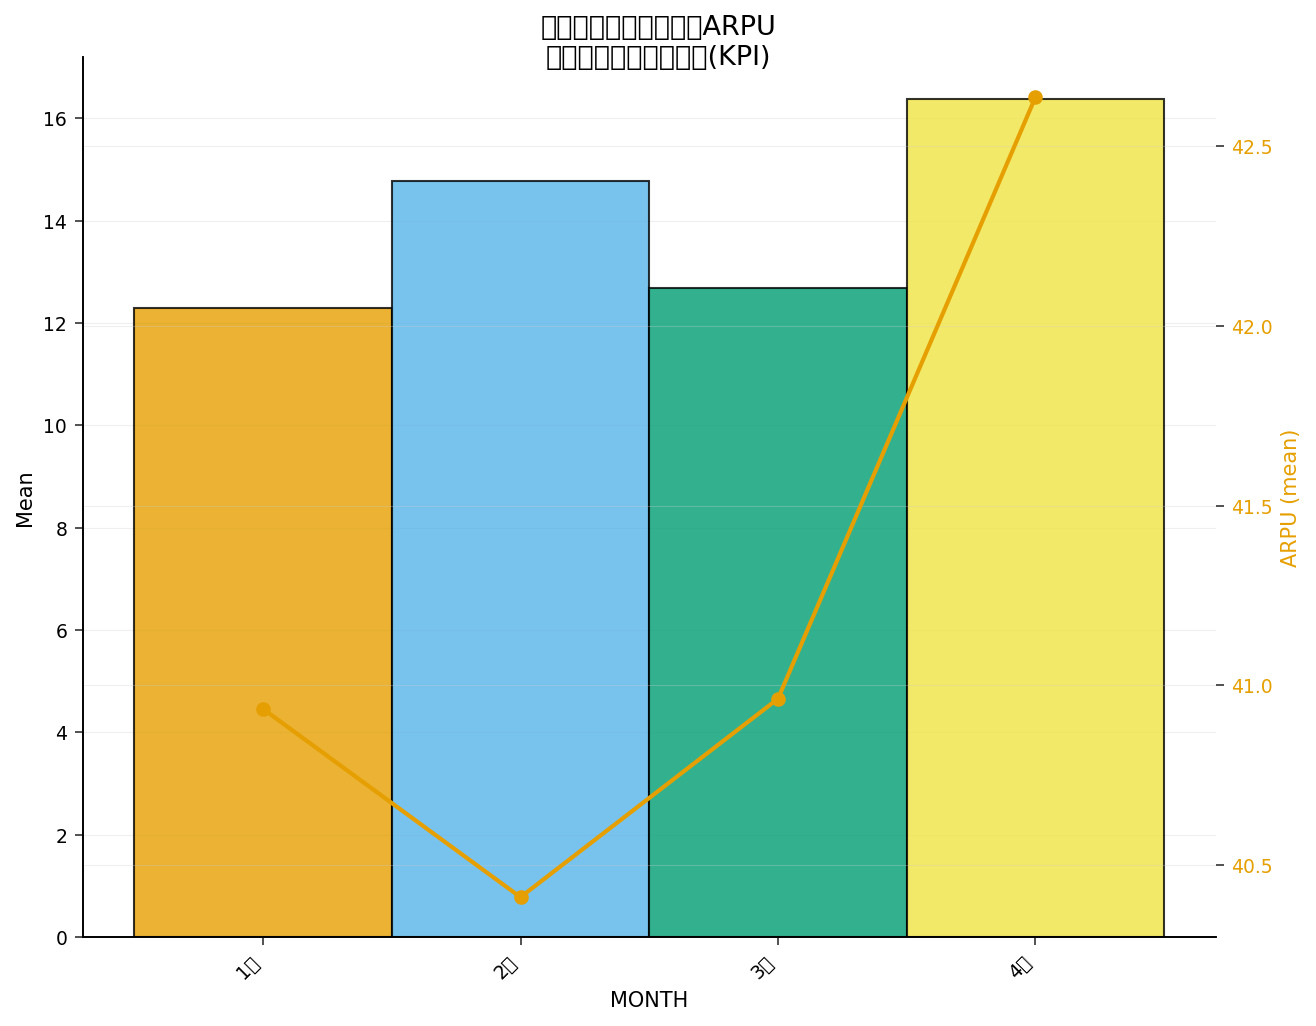

In [2]:
ODS GRAPHICS ON;
标题 "月度移动数据使用量与ARPU";
title2 "模拟电信网络关键指标(KPI)";

过程 gbarline 数据=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
    标签 month="月份" data_gb="数据使用量(GB)" arpu="ARPU(美元)";
运行;


## 步骤3 —— 按套餐拆分使用量,叠加流失率

将 `TYPE=mean` 替换为 `TYPE=sum` 并添加 `SUBGROUP=plan`,可以按套餐等级堆叠每个月份的柱子,从而看出哪个细分市场驱动了总量。叠加的 `LINE` 现在以针状图(`STAT=sum TYPE=needle`)绘制月度流失事件**计数**——垂直的尖峰形态,更自然地体现离散事件计数,而非平滑趋势。

                                                    各套餐数据使用量与月度流失情况                                                     
                                                    模拟电信网络关键指标(KPI)                                                     




NOTE: Option TITLE changed to 各套餐数据使用量与月度流失情况.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


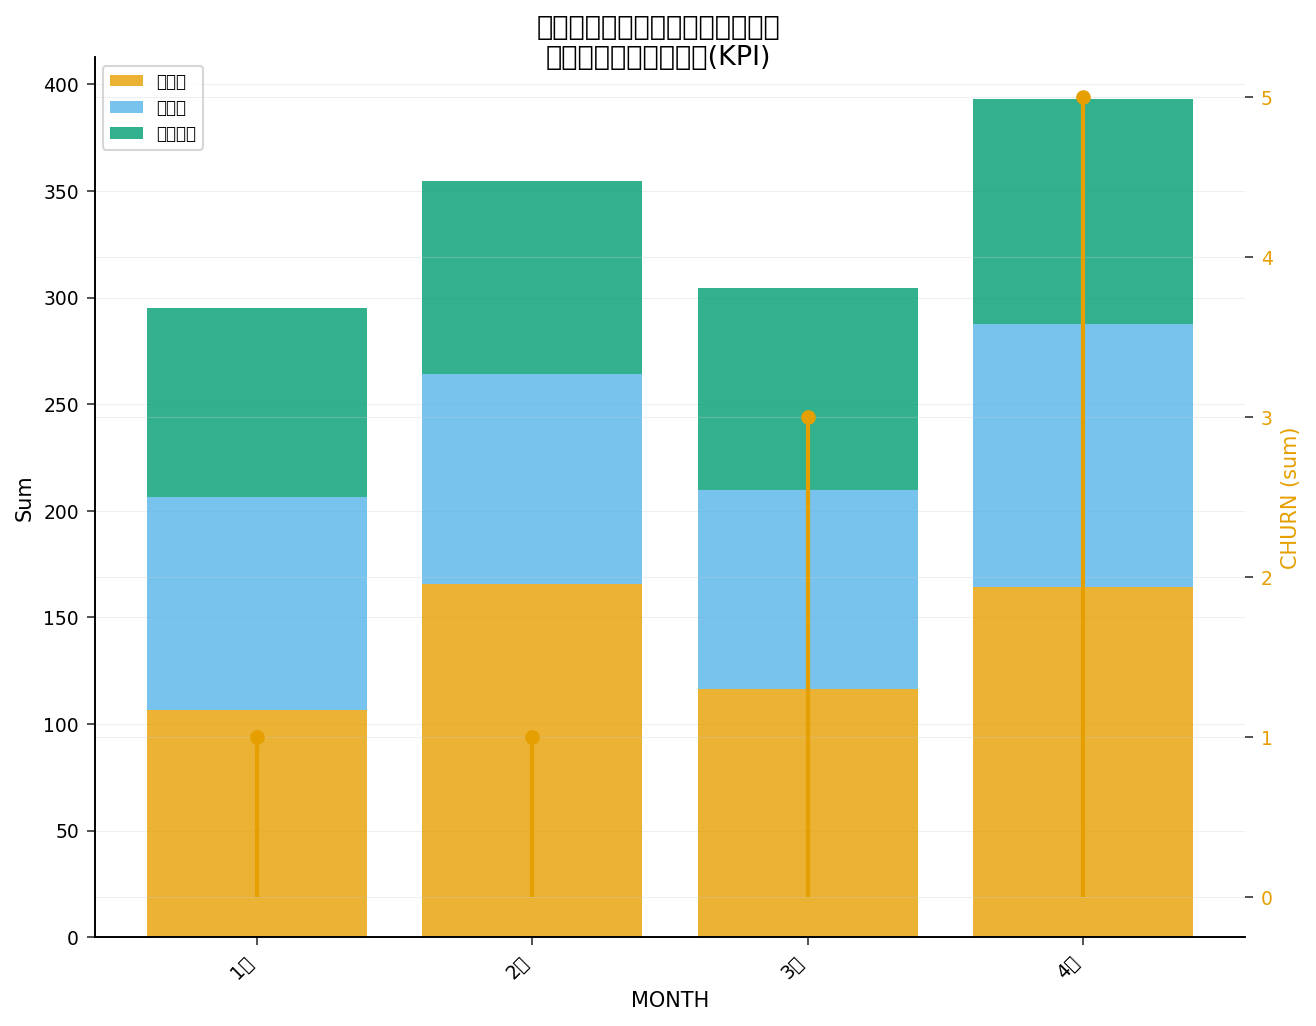

In [3]:
标题 "各套餐数据使用量与月度流失情况";

过程 gbarline 数据=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
    标签 month="月份" data_gb="数据使用量(GB)" plan="套餐类型" churn="流失(0/1)";
运行;


## 步骤4 —— 控制右轴与折线标记

为了得到可发布的图表,我们使用 `AXIS` 定义将绘图(右)轴固定为一个范围并加上标签,然后通过 `RAXIS=axis2` 将其绑定到折线。`SYMBOL` 定义为ARPU折线赋予红色圆点标记。我们还使用 `OUTSIDE=sum` 在每根柱子上方显示柱子总计。

                                                 总使用量(柱状)与平均ARPU(折线)对比                                                  
                                                    模拟电信网络关键指标(KPI)                                                     




NOTE: Option TITLE changed to 总使用量(柱状)与平均ARPU(折线)对比.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


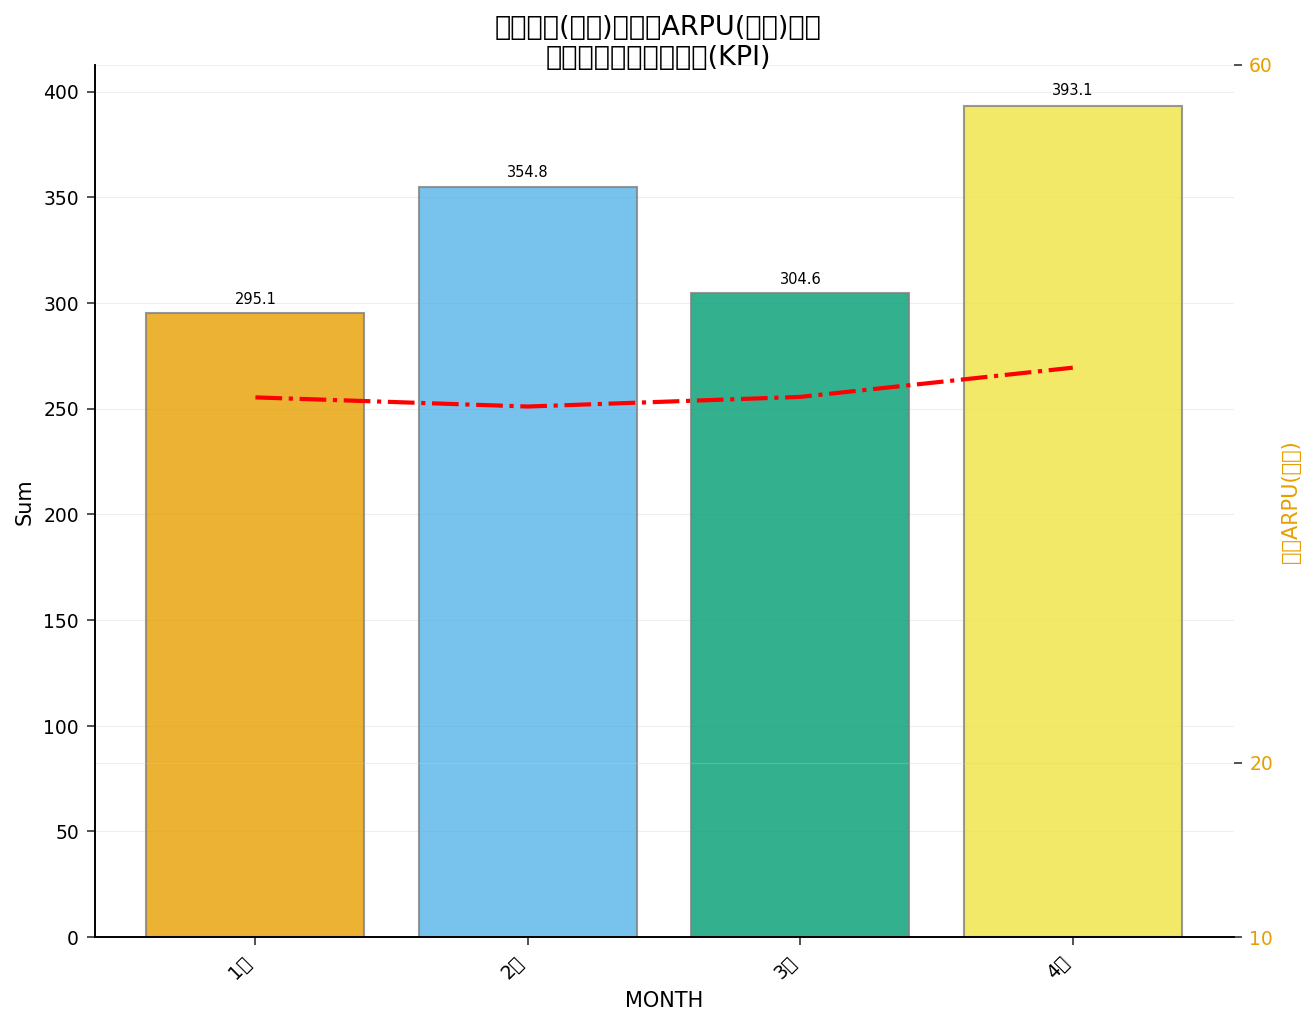

In [4]:
标题 "总使用量(柱状)与平均ARPU(折线)对比";

过程 gbarline 数据=telco_kpi;
    axis2 ORDER=(20 到 60 按照 10) 标签=("平均ARPU(美元)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    标签 month="月份" data_gb="数据使用量(GB)" arpu="ARPU(美元)";
运行;


## 步骤5 —— 使用自定义图例的多条折线叠加

`GBARLINE` 支持一个以上的 `LINE` 语句,因此我们可以同时将两个运营信号与使用量柱状图进行比较:平均支持工单数(`type=join`)和总流失率(`type=needle`)。位于底部的 `LEGEND` 定义记录了套餐子分组。

                                                       支持工单与流失趋势                                                        
                                                    模拟电信网络关键指标(KPI)                                                     




NOTE: Option TITLE changed to 支持工单与流失趋势.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


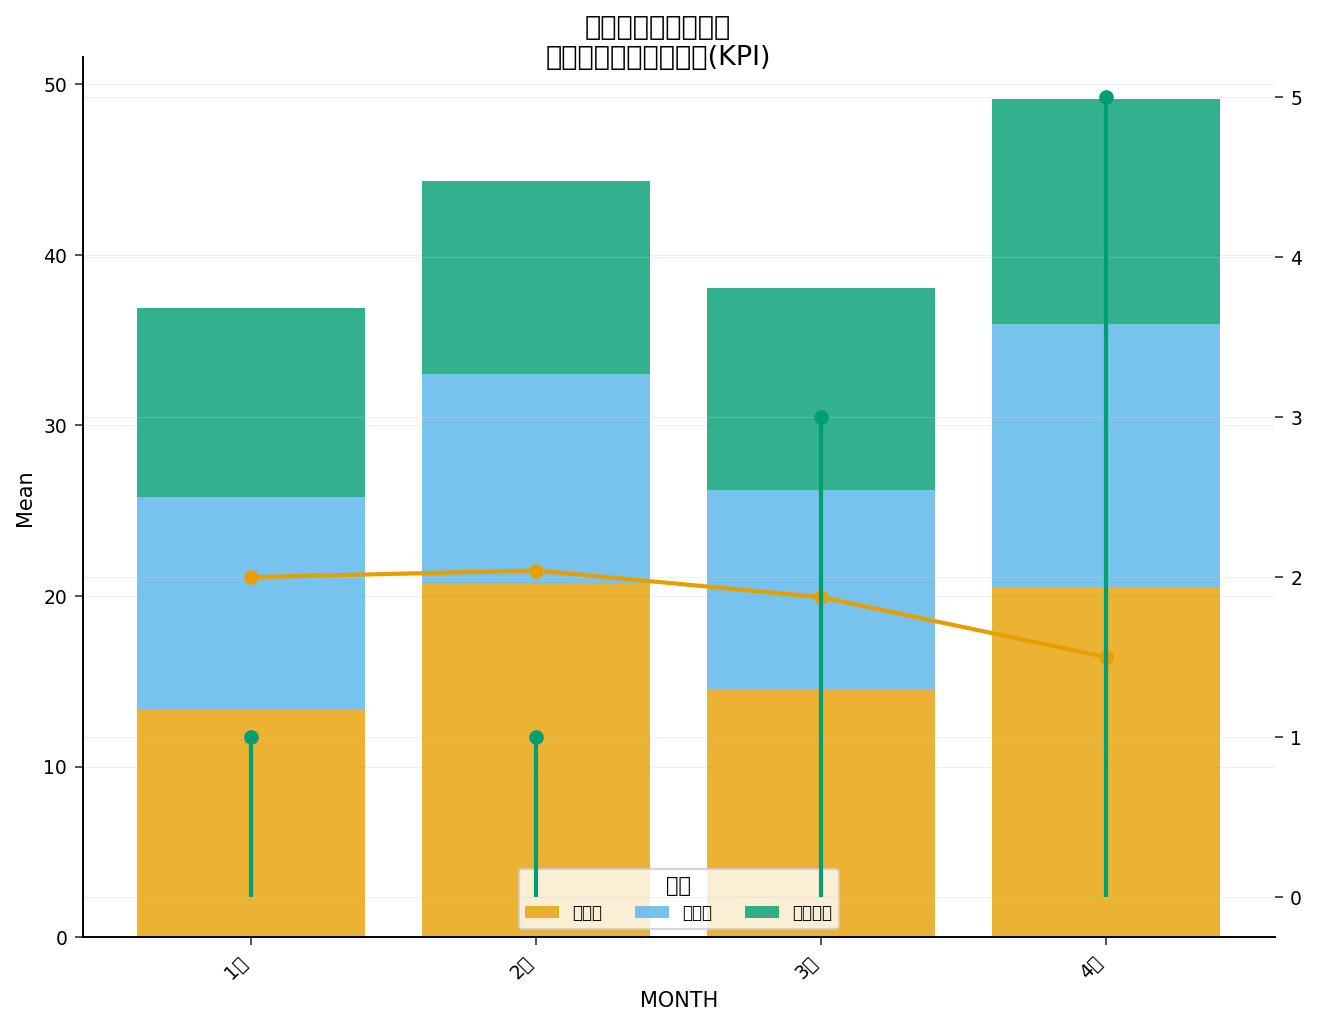

In [5]:
标题 "支持工单与流失趋势";

过程 gbarline 数据=telco_kpi;
    legend1 标签=("套餐") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    标签 month="月份" data_gb="数据使用量(GB)" plan="套餐类型"
          tickets="支持工单数" churn="流失(0/1)";
运行;

ODS GRAPHICS OFF;


## 结果解读

在1月-4月的窗口内,该仪表盘呈现出连贯一致的电信故事。**数据使用量**(柱状图)逐月起伏,但整体呈上升趋势,在**4月**达到峰值——平均使用量从1月的约12.3GB攀升到4月的16.4GB(步骤2),总使用量从295GB增长到393GB(步骤4中的 `OUTSIDE=sum` 标签)。**ARPU折线**在2月略有下降,随后攀升至4月自身的高点,接近42.6美元,说明运营商正越来越多地将额外消耗变现,而不是白白让出——步骤4中的右轴被固定在20-60美元之间,以保持这一变化清晰可读。

按套餐堆叠的视图(步骤3和步骤5)揭示了定义预付费主导型运营商的细分市场张力。**预付费**(橙色条带)总体消耗的千兆字节最多——整个四个月合计约553GB,而后付费为415GB,家庭套餐为380GB——但它的每用户平均收入却**最低**(约36美元,而后付费为41美元,家庭套餐为47美元)。**流失针状图**证实了留存风险的所在:流失事件集中在预付费和后付费等级(整个窗口内各4次),在家庭套餐上较轻(2次),并且随着用户基数和使用量的扩大,流失事件在4月前有所增多。

步骤5在此基础上叠加了运营负担:平均**支持工单数**在期初略高,到4月有所缓解,而流失针状图的峰值出现得更晚——这正是留存团队需要关注的信号。从运营角度看,应将留存投入集中在**预付费**用户身上,他们消耗着增长最快的数据量份额,却贡献了最少的收入和最多的流失。

`PROC GBARLINE` 正是这里的合适工具,因为它将千兆字节量级的柱状图与美元/计数量级的折线图保持在独立的坐标轴上,让每个KPI都能按其自身的量级来解读,同时仍共享月度时间轴。